# Backward Wrought: Find Alloys for Target Properties

Loads the **synthetic_wrought.csv** search pool (from 06_generate_synthetic_wrought). You specify desired properties (e.g. UTS, Yield Strength, Conductivity); the notebook finds the top candidate alloys by filtering/sorting the pool. No training—run 01, 02, and 06 first.

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

INPUT_COLS = ['Al', 'Si', 'Fe', 'Cu', 'Mn', 'Mg', 'Cr', 'Ni', 'Zn', 'Ga', 'V', 'Ti']
POOL_PATH = 'synthetic_wrought.csv'
TOP_K = 3

In [2]:
# Load synthetic pool (run 06_generate_synthetic_wrought.ipynb first)
if not os.path.exists(POOL_PATH):
    raise FileNotFoundError(f'Not found: {POOL_PATH}. Run 06_generate_synthetic_wrought.ipynb first.')
pool = pd.read_csv(POOL_PATH)
prop_cols = [c for c in pool.columns if c not in INPUT_COLS and c != 'El (%)']
print(f'Loaded pool: {pool.shape}. Property columns: {prop_cols}')

Loaded pool: (50000, 25). Property columns: ['UTS (MPa)', 'YS (MPa)', 'Fatigue Strength (MPa)', 'Shear Strength (MPa)', 'Y (GPa)', 'G (GPa)', 'Density (g/cc)', 'Cp (J/kg-K)', 'TC (W/m-K)', 'TE Coeff', 'Thermal Diffusivity ', 'EC Volume (% IACS)', 'EC Weight (% IACS)']


In [3]:
# Set your target properties (column name -> desired value). Use exact names from pool.
# Example: UTS 550 MPa, Yield 400 MPa, Conductivity 40 %IACS (if column exists)
TARGETS = {
    'UTS (MPa)': 550,
    'YS (MPa)': 400,
}
# Add conductivity if your pool has it, e.g. 'EC Volume (% IACS)': 40

In [4]:
# Filter to targets that exist in pool; compute weighted total error and sort
targets_in_pool = {k: v for k, v in TARGETS.items() if k in pool.columns}
if not targets_in_pool:
    raise ValueError('None of TARGETS keys found in pool. Available:', prop_cols)

df = pool.copy()
total_error = np.zeros(len(df))
for col, target_val in targets_in_pool.items():
    scale = max(abs(target_val), 1.0) if target_val != 0 else 1.0
    total_error += np.abs(df[col].values - target_val) / scale
df['Total_Error'] = total_error
winners = df.sort_values('Total_Error').head(TOP_K)

print(f"[{'='*25} BACKWARD WROUGHT: OPTIMAL ALLOYS {'='*25}]")
print(f"  Target properties: {targets_in_pool}\n")
for i, (idx, row) in enumerate(winners.iterrows()):
    print(f"--- CANDIDATE #{i+1} ---")
    for col in targets_in_pool:
        print(f"  {col}: {row[col]:.2f}")
    comp = {el: float(row[el]) for el in INPUT_COLS}
    total = sum(comp.values())
    if total < 100.0:
        comp['Al'] = comp['Al'] + (100.0 - total)
    elif total > 100.0:
        scale = 100.0 / total
        comp = {el: comp[el] * scale for el in INPUT_COLS}
    recipe = [f"{el}={comp[el]:.2f}%" for el in INPUT_COLS if comp[el] > 0.1]
    print("  Recipe: " + ", ".join(recipe))
    print("  Total: 100.00%")
    print()

[========================= BACKWARD WROUGHT: OPTIMAL ALLOYS =========================]
  Target properties: {'UTS (MPa)': 550, 'YS (MPa)': 400}

--- CANDIDATE #1 ---
  UTS (MPa): 560.13
  YS (MPa): 411.16
  Recipe: Al=93.59%, Si=0.12%, Fe=0.15%, Cu=1.70%, Mg=2.30%, Zn=2.00%
  Total: 100.00%

--- CANDIDATE #2 ---
  UTS (MPa): 560.13
  YS (MPa): 411.16
  Recipe: Al=93.59%, Si=0.12%, Fe=0.15%, Cu=1.70%, Mn=0.10%, Mg=2.30%, Zn=2.00%
  Total: 100.00%

--- CANDIDATE #3 ---
  UTS (MPa): 560.13
  YS (MPa): 411.16
  Recipe: Al=93.59%, Si=0.12%, Fe=0.15%, Cu=1.70%, Mg=2.30%, Zn=2.00%
  Total: 100.00%



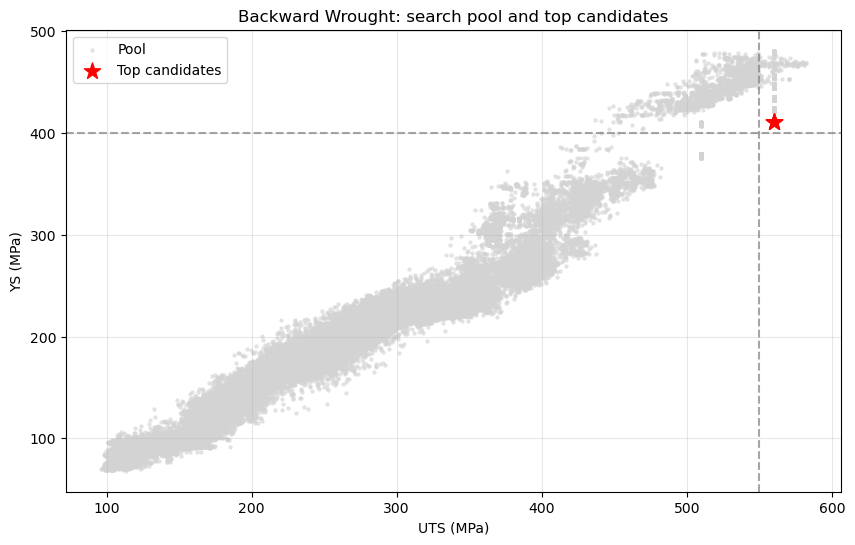

In [5]:
# Optional: 2D plot if exactly two target properties
if len(targets_in_pool) == 2:
    cols = list(targets_in_pool.keys())
    plt.figure(figsize=(10, 6))
    plt.scatter(pool[cols[0]], pool[cols[1]], c='lightgray', s=5, alpha=0.5, label='Pool')
    plt.scatter(winners[cols[0]], winners[cols[1]], c='red', s=150, marker='*', label='Top candidates')
    plt.axvline(TARGETS.get(cols[0]), color='gray', linestyle='--', alpha=0.7)
    plt.axhline(TARGETS.get(cols[1]), color='gray', linestyle='--', alpha=0.7)
    plt.xlabel(cols[0])
    plt.ylabel(cols[1])
    plt.title('Backward Wrought: search pool and top candidates')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print('(Plot skipped: set exactly 2 targets for 2D plot)')